<a href="https://colab.research.google.com/github/Mithiles-19/OIBSIP/blob/main/Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path="/content/retail_sales_dataset.csv"
df=pd.read_csv(file_path)
print(df.head())
print(df.info())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   obj

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print("\nMisssing values per column:")
print(df.isna().sum())
df=df.dropna(subset=["Date"])
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"\nRemoved {before - after} duplicate rows")
print("\nDescriptive stats (numeric columns):")
print(df.describe())


Misssing values per column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Removed 0 duplicate rows

Descriptive stats (numeric columns):
       Transaction ID                           Date         Age     Quantity  \
count     1000.000000                           1000  1000.00000  1000.000000   
mean       500.500000  2023-07-03 00:25:55.200000256    41.39200     2.514000   
min          1.000000            2023-01-01 00:00:00    18.00000     1.000000   
25%        250.750000            2023-04-08 00:00:00    29.00000     1.000000   
50%        500.500000            2023-06-29 12:00:00    42.00000     3.000000   
75%        750.250000            2023-10-04 00:00:00    53.00000     4.000000   
max       1000.000000            2024-01-01 00:00:00    64.00000     4.000000   
std        288.819436                           

In [ ]:
num_cols = ["Quantity", "Price per Unit", "Total Amount", "Age"]
print("\nDescriptive statistics:")
print(df[num_cols].describe())
print("\nMeans:")
print(df[num_cols].mean())
print("\nMedians:")
print(df[num_cols].median())
print("\nStandard deviations:")
print(df[num_cols].std())
print("\nModes:")
print(df[num_cols].mode().iloc[0])


Descriptive statistics:
          Quantity  Price per Unit  Total Amount         Age
count  1000.000000     1000.000000   1000.000000  1000.00000
mean      2.514000      179.890000    456.000000    41.39200
std       1.132734      189.681356    559.997632    13.68143
min       1.000000       25.000000     25.000000    18.00000
25%       1.000000       30.000000     60.000000    29.00000
50%       3.000000       50.000000    135.000000    42.00000
75%       4.000000      300.000000    900.000000    53.00000
max       4.000000      500.000000   2000.000000    64.00000

Means:
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
Age                41.392
dtype: float64

Medians:
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
Age                42.0
dtype: float64

Standard deviations:
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
Age                13.681430
dtype: float64

Modes:
Quantity         


Daily sales head:
Date
2023-01-01    3600
2023-01-02    1765
2023-01-03     600
2023-01-04    1240
2023-01-05    1100
Name: Total Amount, dtype: int64


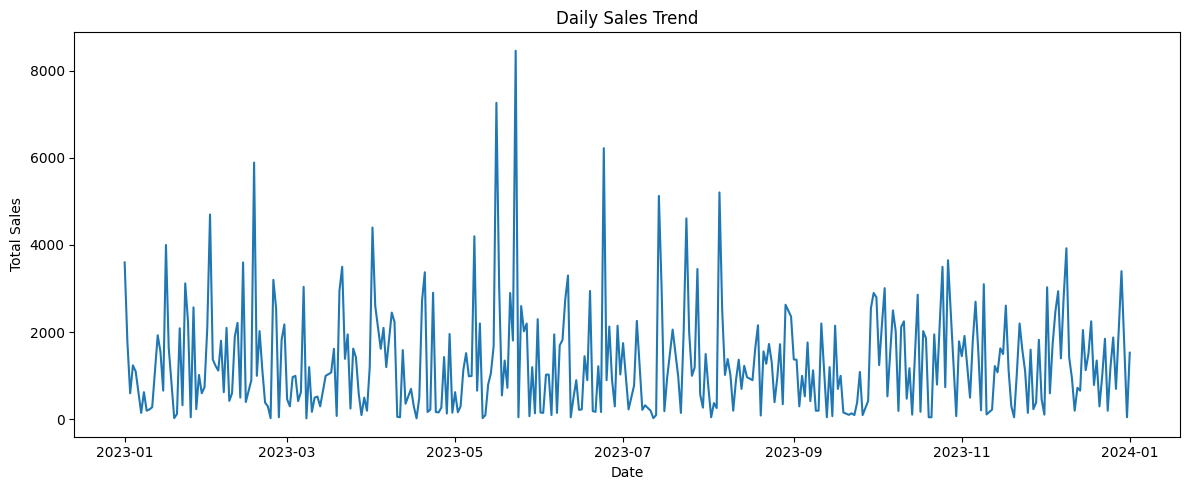

In [ ]:
df = df.sort_values("Date")
daily_sales = df.groupby("Date")["Total Amount"].sum()
print("\nDaily sales head:")
print(daily_sales.head())
plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales.values)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Daily Sales Trend")
plt.tight_layout()
plt.show()

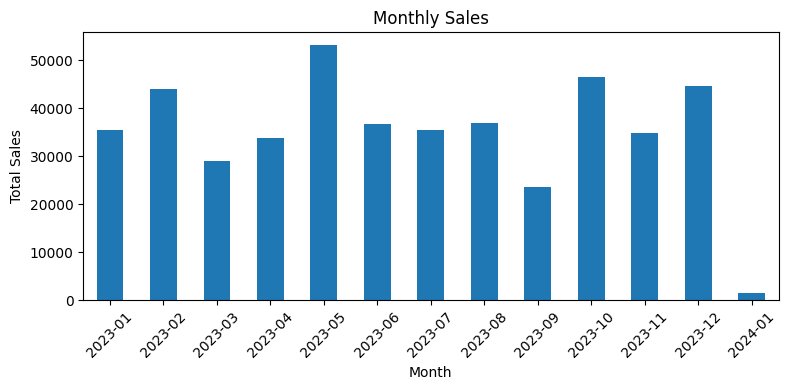

In [ ]:
df["YearMonth"] = df["Date"].dt.to_period("M")
monthly_sales = df.groupby("YearMonth")["Total Amount"].sum()

plt.figure(figsize=(8, 4))
monthly_sales.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Sales by Product Category:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


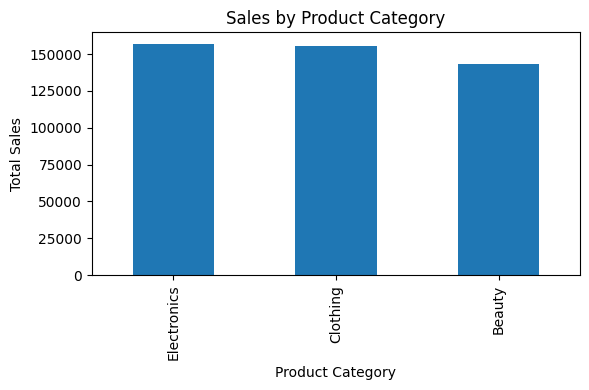

In [ ]:
cat_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)
print("\nSales by Product Category:")
print(cat_sales)
plt.figure(figsize=(6, 4))
cat_sales.plot(kind="bar")
plt.ylabel("Total Sales")
plt.title("Sales by Product Category")
plt.tight_layout()
plt.show()



Sales by Gender:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


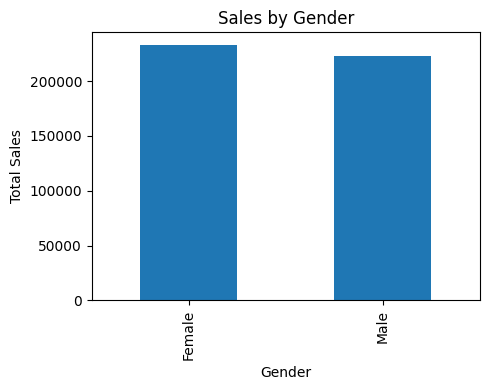

In [ ]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()
print("\nSales by Gender:")
print(gender_sales)
plt.figure(figsize=(5, 4))
gender_sales.plot(kind="bar")
plt.ylabel("Total Sales")
plt.title("Sales by Gender")
plt.tight_layout()
plt.show()


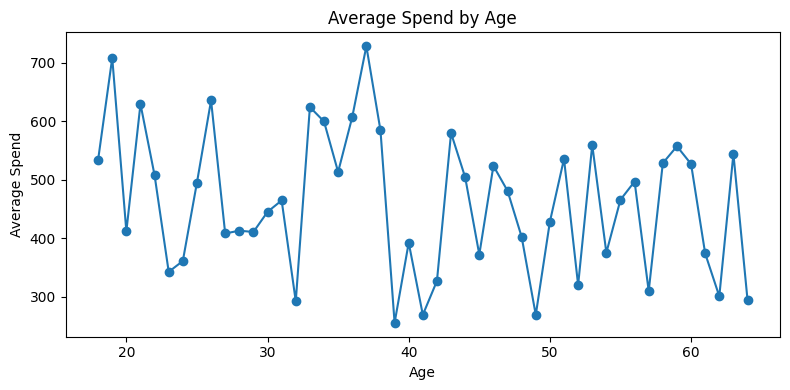

In [ ]:
# Average spend per age
age_sales = df.groupby("Age")["Total Amount"].mean()

plt.figure(figsize=(8, 4))
plt.plot(age_sales.index, age_sales.values, marker="o")
plt.xlabel("Age")
plt.ylabel("Average Spend")
plt.title("Average Spend by Age")
plt.tight_layout()
plt.show()


Correlation matrix:
                Quantity  Price per Unit  Total Amount       Age
Quantity        1.000000        0.017501      0.373707 -0.023737
Price per Unit  0.017501        1.000000      0.851925 -0.038423
Total Amount    0.373707        0.851925      1.000000 -0.060568
Age            -0.023737       -0.038423     -0.060568  1.000000


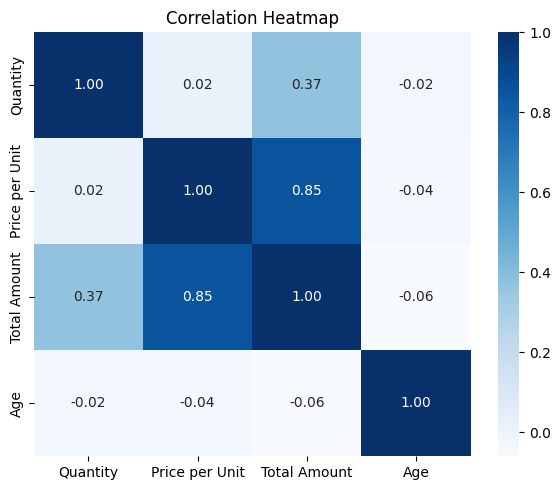

In [ ]:
corr = df[["Quantity", "Price per Unit", "Total Amount", "Age"]].corr()
print("\nCorrelation matrix:")
print(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


Average Order Value (AOV): 456.00

Category revenue share (%):
Product Category
Electronics    34.408991
Clothing       34.118421
Beauty         31.472588
Name: Total Amount, dtype: float64

Gender revenue share (%):
Gender
Female    51.061404
Male      48.938596
Name: Total Amount, dtype: float64

Sales by Age Group:
Age Group
18–25     73335
26–35     98480
36–45     91870
46–55    100690
56–65     80410
Name: Total Amount, dtype: int64


/tmp/ipython-input-431437970.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_sales = df.groupby("Age Group")["Total Amount"].sum()


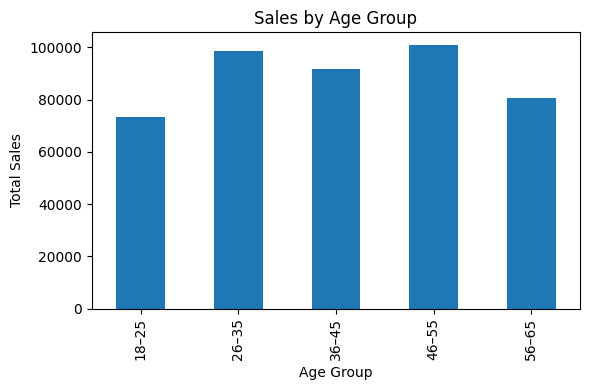

In [ ]:
# Average order value
aov = df["Total Amount"].mean()
print(f"\nAverage Order Value (AOV): {aov:.2f}")

# Category share of total revenue
cat_share = (cat_sales / df["Total Amount"].sum()) * 100
print("\nCategory revenue share (%):")
print(cat_share)

# Gender share of revenue
gender_share = (gender_sales / df["Total Amount"].sum()) * 100
print("\nGender revenue share (%):")
print(gender_share)

# Age group analysis (bins)
bins = [18, 25, 35, 45, 55, 65]
labels = ["18–25", "26–35", "36–45", "46–55", "56–65"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True)

age_group_sales = df.groupby("Age Group")["Total Amount"].sum()
print("\nSales by Age Group:")
print(age_group_sales)

plt.figure(figsize=(6, 4))
age_group_sales.plot(kind="bar")
plt.ylabel("Total Sales")
plt.title("Sales by Age Group")
plt.tight_layout()
plt.show()
